In [1]:
import os
import pypsa
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

from unit_helpers import (
    tj_to_twh,
    bcm_to_twh,
)

/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/google/cloud/storage/__init__.py:35: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


In [14]:
path = Path.cwd().parent / 'resources'
regions = gpd.read_file(path / 'regions_onshore_base_s_50.geojson')
path = Path.cwd().parent / 'results' / 'networks'
n = pypsa.Network(path / 'base_s_50_24H_24H-T-H-B-I-A-dist1_2025.nc')

/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/pyogrio/__init__.py:7: DeprecationWarning: The 'shapely.geos' module is deprecated, and will be removed in a future version. All attributes of 'shapely.geos' are available directly from the top-level 'shapely' namespace (since shapely 2.0.0).
  import shapely.geos  # noqa: F401
INFO:pypsa.io:Imported network base_s_50_24H_24H-T-H-B-I-A-dist1_2025.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [9]:
from gas_validaion_data import (
    ds_2024_residential,
    ds_2024_industrial,
    df_2024_production,
    df_pipeline_imports,
    df_total_supply,
    df_storage_2024,
)

ds_2024_residential = bcm_to_twh(ds_2024_residential)
ds_2024_industrial = bcm_to_twh(ds_2024_industrial)
df_2024_production = bcm_to_twh(df_2024_production)
df_pipeline_imports = bcm_to_twh(df_pipeline_imports)
df_total_supply = bcm_to_twh(df_total_supply)
df_storage_2024 = bcm_to_twh(df_storage_2024)

ccon = pd.read_csv(
    'nrg_cb_gas$defaultview_linear_2_0.csv'
)
ccon = (
    ccon.loc[ccon['TIME_PERIOD'] == 2024]
    .set_index('Geopolitical entity (reporting)')
    ['OBS_VALUE']
    .rename('gas_demand')
    .apply(tj_to_twh)
)

In [4]:
df_total_supply.head()

,Production,Pipeline_Import,LNG_Sendout,Net_Storage_Withdrawal,Re_exports,Total_Supply
Quarter,,,,,,
Q2-2023,16.6,43.6,40.0,-22.8,-0.4,76.9
Q3-2023,15.6,44.3,29.9,-20.4,-2.8,66.8
Q4-2023,16.4,51.9,37.0,9.8,-1.0,114.5
Q1-2024,16.2,50.9,34.0,29.3,-0.3,130.1
Q2-2024,14.7,49.7,28.1,-19.4,-0.3,72.4


In [19]:
# Helper to add a shared title above both axes in a row, centered horizontally
def add_shared_row_title(fig, ax_left, ax_right, title, row_idx):

    fig.canvas.draw()
    bbox_left = ax_left.get_position()
    bbox_right = ax_right.get_position()

    x = (bbox_left.x0 + bbox_right.x1) / 2

    y = bbox_left.y1 + 0.01
    fig.text(x, y, title, ha='center', va='bottom', fontsize=12, fontweight='bold')

In [ ]:
def plot_total_gas_supply(ax_left, ax_right, n, right_data, fig, row_idx):

    ax_left.text(0.5, 0.5, "Model\nData\n1", ha='center', va='center', fontsize=14)
    ax_right.text(0.5, 0.5, "True\nData\n1", ha='center', va='center', fontsize=14)
    
    ax_left.set_xticks([]); ax_left.set_yticks([])
    ax_right.set_xticks([]); ax_right.set_yticks([])

    add_shared_row_title(fig, ax_left, ax_right, "Row 1: Gas Production", row_idx)

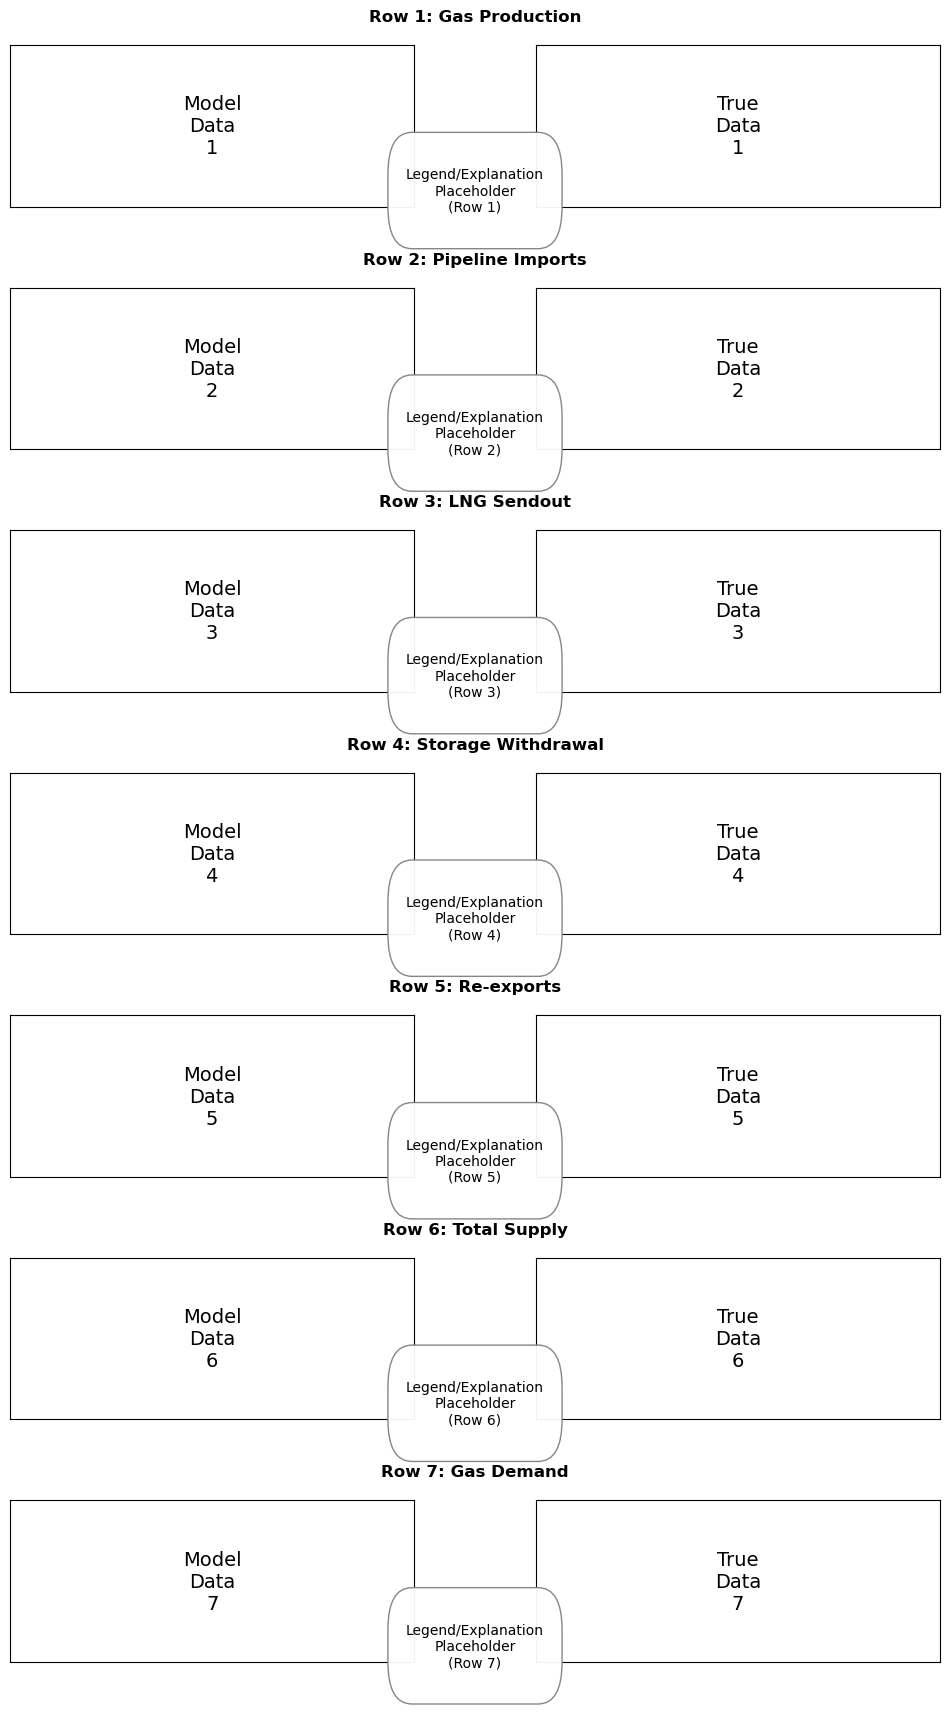

In [ ]:
import matplotlib.patches as patches

# Define placeholder functions for each row
# Define one function per row, each taking (ax_left, ax_right, n, right_data, fig, row_idx)

def plot_row2(ax_left, ax_right, n, right_data, fig, row_idx):

    ax_left.text(0.5, 0.5, "Model\nData\n2", ha='center', va='center', fontsize=14)
    ax_right.text(0.5, 0.5, "True\nData\n2", ha='center', va='center', fontsize=14)

    ax_left.set_xticks([]); ax_left.set_yticks([])
    ax_right.set_xticks([]); ax_right.set_yticks([])

    add_shared_row_title(fig, ax_left, ax_right, "Row 2: Pipeline Imports", row_idx)


def plot_row3(ax_left, ax_right, n, right_data, fig, row_idx):

    ax_left.text(0.5, 0.5, "Model\nData\n3", ha='center', va='center', fontsize=14)
    ax_right.text(0.5, 0.5, "True\nData\n3", ha='center', va='center', fontsize=14)

    ax_left.set_xticks([]); ax_left.set_yticks([])
    ax_right.set_xticks([]); ax_right.set_yticks([])

    add_shared_row_title(fig, ax_left, ax_right, "Row 3: LNG Sendout", row_idx)


def plot_row4(ax_left, ax_right, n, right_data, fig, row_idx):

    ax_left.text(0.5, 0.5, "Model\nData\n4", ha='center', va='center', fontsize=14)
    ax_right.text(0.5, 0.5, "True\nData\n4", ha='center', va='center', fontsize=14)

    ax_left.set_xticks([]); ax_left.set_yticks([])
    ax_right.set_xticks([]); ax_right.set_yticks([])

    add_shared_row_title(fig, ax_left, ax_right, "Row 4: Storage Withdrawal", row_idx)


def plot_row5(ax_left, ax_right, n, right_data, fig, row_idx):

    ax_left.text(0.5, 0.5, "Model\nData\n5", ha='center', va='center', fontsize=14)
    ax_right.text(0.5, 0.5, "True\nData\n5", ha='center', va='center', fontsize=14)

    ax_left.set_xticks([]); ax_left.set_yticks([])
    ax_right.set_xticks([]); ax_right.set_yticks([])

    add_shared_row_title(fig, ax_left, ax_right, "Row 5: Re-exports", row_idx)


def plot_row6(ax_left, ax_right, n, right_data, fig, row_idx):

    ax_left.text(0.5, 0.5, "Model\nData\n6", ha='center', va='center', fontsize=14)
    ax_right.text(0.5, 0.5, "True\nData\n6", ha='center', va='center', fontsize=14)

    ax_left.set_xticks([]); ax_left.set_yticks([])
    ax_right.set_xticks([]); ax_right.set_yticks([])

    add_shared_row_title(fig, ax_left, ax_right, "Row 6: Total Supply", row_idx)


def plot_row7(ax_left, ax_right, n, right_data, fig, row_idx):

    ax_left.text(0.5, 0.5, "Model\nData\n7", ha='center', va='center', fontsize=14)
    ax_right.text(0.5, 0.5, "True\nData\n7", ha='center', va='center', fontsize=14)

    ax_left.set_xticks([]); ax_left.set_yticks([])
    ax_right.set_xticks([]); ax_right.set_yticks([])

    add_shared_row_title(fig, ax_left, ax_right, "Row 7: Gas Demand", row_idx)


fig_height = 3 * 7  # 3 inches per row
fig_width = 12      # 2*2*3 = 12 inches for 2:1 aspect per ax, 2 axes per row
fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(fig_width, fig_height), gridspec_kw={'wspace':0.3, 'hspace':0.5})

row_fns = [
    plot_total_gas_supply,
    plot_row2,
    plot_row3,
    plot_row4,
    plot_row5,
    plot_row6,
    plot_row7,
]

right_data_list = [None]*7

for i in range(7):
    model_ax = axes[i, 0]
    true_ax = axes[i, 1]
    row_fns[i](model_ax, true_ax, n, right_data_list[i], fig, i)

    model_ax.set_xlabel("")
    model_ax.set_ylabel("")
    true_ax.set_xlabel("")
    true_ax.set_ylabel("")

    fig.canvas.draw()  # Needed to ensure positions are up to date
    bbox1 = model_ax.get_position()
    bbox2 = true_ax.get_position()

    x0 = bbox1.x1 - 0.02 * (bbox2.x0 - bbox1.x1)  # slight overlap
    width = bbox2.x0 - bbox1.x1 + 0.04 * (bbox2.x0 - bbox1.x1)
    y0 = bbox1.y0
    height = bbox1.height

    bbox_top = model_ax.get_position()
    bbox_bottom = model_ax.get_position()
    y0 = bbox_bottom.y0
    height = (bbox_top.y1 - bbox_bottom.y0) / 5

    rect = patches.FancyBboxPatch(
        (x0, y0), width, height,
        boxstyle="round,pad=0.02",
        linewidth=1, edgecolor='gray', facecolor='white', alpha=0.95,
        transform=fig.transFigure, zorder=10
    )

    fig.patches.append(rect)

    fig.text(
        x0 + width/2, y0 + height/2,
        f"Legend/Explanation\nPlaceholder\n(Row {i+1})",
        ha='center', va='center', fontsize=10, color='black', zorder=11
    )

plt.show()

In [ ]:
ss = n.statistics.withdrawal(groupby=['carrier', 'bus'], aggregate_time=False)
ss = ss.loc[ss.index.get_level_values(2).str.contains('gas')].dropna()

In [25]:
ss.index.get_level_values(1).unique()

Index(['Combined-Cycle Gas', 'Open-Cycle Gas', 'SMR', 'SMR CC',
       'biogas to gas', 'gas for industry', 'gas for industry CC',
       'gas pipeline', 'gas pipeline new', 'services rural gas boiler',
       'services urban decentral gas boiler', 'urban central gas CHP',
       'urban central gas CHP CC', 'urban central gas boiler'],
      dtype='object', name='carrier')

In [61]:
gas_demand = (
    ss.groupby(level=1).sum()
    .dropna()
    .drop(['gas pipeline', 'gas pipeline new', 'biogas to gas'])
    .T
    / 1e6 * 24
)
gas_demand.index = gas_demand.index.strftime('%Y-%m-%d')
gas_demand = gas_demand.groupby(gas_demand.index.str[:7]).sum().T

In [62]:
industry_demands = ['gas for industry', 'gas for industry CC', 'SMR', 'SMR CC']
rescom_demands = ['services rural gas boiler', 'services urban decentral gas boiler', 'urban central gas boiler', 'urban central gas CHP', 'urban central gas CHP CC']

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


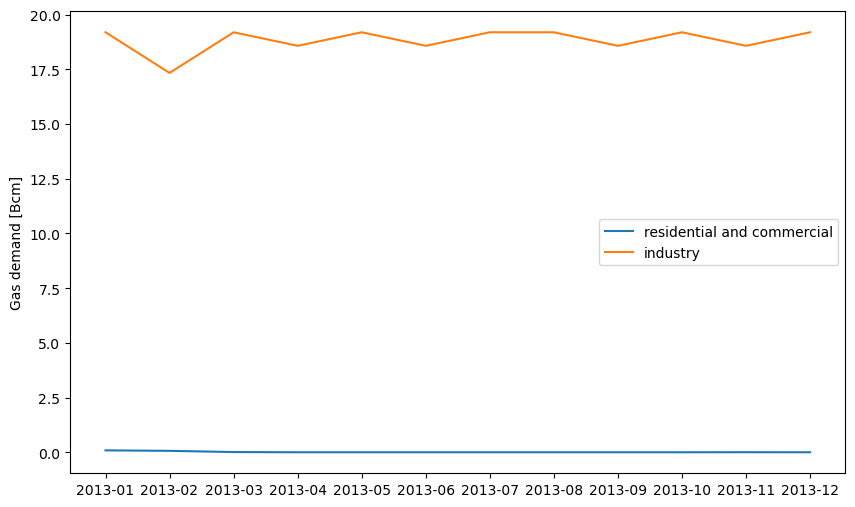

In [65]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(gas_demand.columns, gas_demand.loc[rescom_demands].sum() / 11, label='residential and commercial')
ax.plot(gas_demand.columns, gas_demand.loc[industry_demands].sum() / 11, label='industry')

ax.set_ylabel('Gas demand [Bcm]')
ax.legend()